# 単純パーセプトロンの実装
---
## 目的
これまでに学習した内容を活用して，単純パーセプトロンを実装し学習を行う．

In [14]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

### 単純パーセプトロン
単純パーセプトロンは，ニューラルネットワークの基本的な構成要素の一つで，二値の入力を受け取り，それに対して重み付けされた合計を計算し，活性化関数を適用して出力を生成するモデルです．

単純パーセプトロンは，入力として$\boldsymbol{x}\in\mathbb{R}^{D}$を与えたとき，
$$f(\boldsymbol{x})=\sigma(\boldsymbol{w}\cdot \boldsymbol{x}+\boldsymbol{b})$$
ここで，$\sigma$は活性化関数としてのシグモイド関数であり，$\boldsymbol{w}\in\mathbb{R}^{D}$は重みベクトル，$\boldsymbol{b}\in\mathbb{R}^{D'}$はバイアスである．

【Pytorchでのモデル定義】<br>
単純パーセプトロンは，全結合層と活性化関数のみで設計することが可能です．<br>
そこで，今回は**単純パーセプトロンによるAND回路**を作成します．<br>
AND回路は2つの入力がともに1の場合にのみ，出力が1となります．下記の表はAND回路の真理値表を示しています．
| 入力1 | 入力2 | 出力 |
|-------|-------|------|
|   0   |   0   |   0  |
|   0   |   1   |   0  |
|   1   |   0   |   0  |
|   1   |   1   |   1  |

In [15]:
# ANDゲートの学習データ
training_data = [
    (torch.tensor([0.0, 0.0]), torch.tensor([0.0])),
    (torch.tensor([0.0, 1.0]), torch.tensor([0.0])),
    (torch.tensor([1.0, 0.0]), torch.tensor([0.0])),
    (torch.tensor([1.0, 1.0]), torch.tensor([1.0])),
]

1. ネットワーククラスの定義：<br>
はじめにネットワークのクラスを定義します．これはnn.Moduleを継承するクラスで，__init__メソッドでネットワークの構造を初期化し，forwardメソッドでデータのフォワードパスを定義します．<br>
本モデルでは入力層のユニット数は引数input_sizeとして与え，出力はスカラー値であるので1とします．また，活性化関数にはシグモイド関数を用います．

In [16]:
class SimplePerceptron(nn.Module):
    def __init__(self, input_size):
        super(SimplePerceptron, self).__init__()
        self.linear = nn.Linear(input_size, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))

**__init__メソッド**: ネットワークの初期化を行います．ここで，nn.Linearを使用して入力サイズと出力サイズを指定します．これがネットワークの全結合層（重みとバイアスの結合）を表します．

 **forwardメソッド**: データのフォワードパスを定義します．ここでは，torch.sigmoidを使用して活性化関数（シグモイド関数）を適用します．

2. モデルのインスタンス化:<br>
定義したクラスからモデルのインスタンスを作成します．これには，入力サイズを指定します．

In [17]:
# モデルのインスタンス化
perceptron = SimplePerceptron(input_size=2)
print(perceptron)

SimplePerceptron(
  (linear): Linear(in_features=2, out_features=1, bias=True)
)


3. 損失関数および最適化手法の定義:<br>
ネットワークがどれだけ問題に適合しているかを計算するために，損失関数を定義します．2値分類問題においては，一般的には二値交差エントロピー損失（Binary Cross Entropy Loss）が使われます．<br>
また，パラメータの更新には最適化手法を定義します．今回は，確率的勾配降下法 (Stochastic Gradient Descent: SGD) を使用します．

In [18]:
# 損失関数とオプティマイザの定義
criterion = nn.BCELoss()
optimizer = optim.SGD(perceptron.parameters(), lr=0.5)

4. モデルの学習:
モデルを学習させます．エポック数やバッチサイズなどのハイパーパラメータを設定します．今回は，1データごとに学習を行うオンライン学習で実装します．<br>
学習の際は下記のコマンドを実行します，<br>
optimizer.zero_grad(): 勾配を初期化します．<br>
loss.backward(): 勾配の計算を行います．<br>
optimizer.step(): パラメータの更新を行います．<br>

Epoch 100/1000, Loss: 0.08084281542687677
Epoch 200/1000, Loss: 0.041949948710680474
Epoch 300/1000, Loss: 0.028238499776307435
Epoch 400/1000, Loss: 0.02125937463642913
Epoch 500/1000, Loss: 0.01703785655217871
Epoch 600/1000, Loss: 0.014211212275426988
Epoch 700/1000, Loss: 0.012187047818997598
Epoch 800/1000, Loss: 0.010666431272966292
Epoch 900/1000, Loss: 0.009482554596672799
Epoch 1000/1000, Loss: 0.008534730693753545


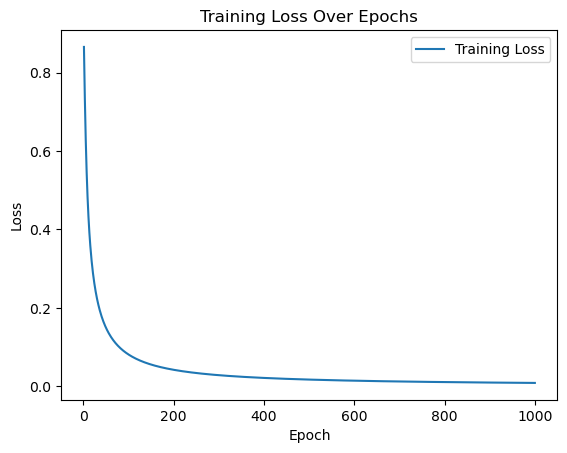

In [19]:
num_epochs = 1000

# 損失の履歴を保存するためのリスト
loss_history = []

# 学習
for epoch in range(num_epochs):
    total_loss = 0
    for input_data, target in training_data:
        optimizer.zero_grad()  # 勾配の初期化
        output = perceptron(input_data)  # フォワードパス
        loss = criterion(output, target)  # 損失の計算
        loss.backward()  # バックワードパス（勾配の計算）
        optimizer.step()  # パラメータの更新
        total_loss += loss.item()
    loss_history.append(total_loss / len(training_data))
    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {total_loss / len(training_data)}')

# 学習の推移をグラフ化
plt.plot(range(1, num_epochs + 1), loss_history, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.show()

5. 学習結果の確認:
学習が終わったら，モデルが正しく学習できたかを評価します．

Input: [0. 0.], Predicted Output: 1.4152788025967311e-06
Input: [0. 1.], Predicted Output: 0.009967907331883907
Input: [1. 0.], Predicted Output: 0.01002962701022625
Input: [1. 1.], Predicted Output: 0.986315131187439


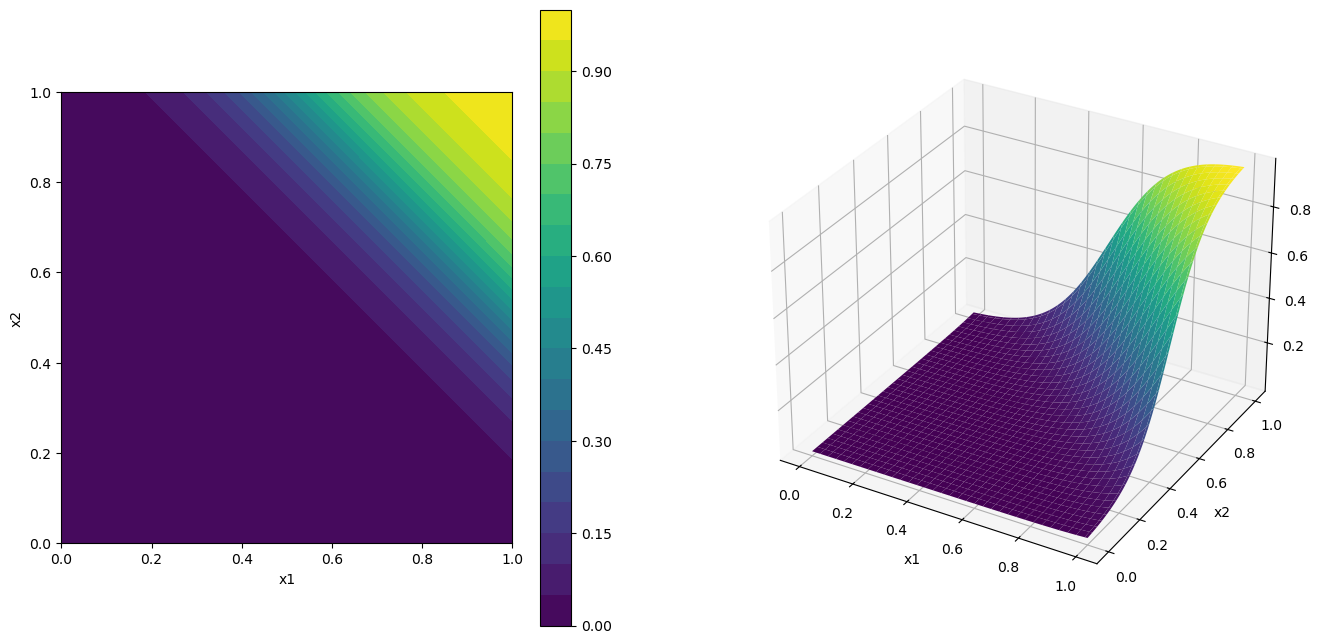

In [20]:
# 学習後のモデルの評価
with torch.no_grad():
    for input_data, _ in training_data:
        prediction = perceptron(input_data)
        print(f'Input: {input_data.numpy()}, Predicted Output: {prediction.item()}')

## 結果を視覚的に出力
# x1とx2の生成
x1 = np.linspace(0, 1, 101)  # [0 0.1 ... 1.0]
x2 = np.linspace(0, 1, 101)  # [0 0.1 ... 1.0]
X1, X2 = np.meshgrid(x1, x2)

# 入力x1とx2の出力を計算しvalに代入
val = []

# perceptron の forward メソッドの戻り値が PyTorch テンソルなので numpy に変換
for v in x2:
    for u in x1:
        input_data = torch.tensor([u, v], dtype=torch.float32)
        output = perceptron.forward(input_data).detach().numpy()
        val.append(output)

val = np.asarray(val)
val = val.reshape(X1.shape)


fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(121)
   
surf = ax.contourf(X1, X2, val, 20, cmap='viridis')
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_aspect('equal') 

ax = fig.add_subplot(122, projection='3d')
ax.plot_surface(X1, X2, val, cmap='viridis') 
ax.set_xlabel("x1")
ax.set_ylabel("x2")
fig.colorbar(surf)
plt.show()